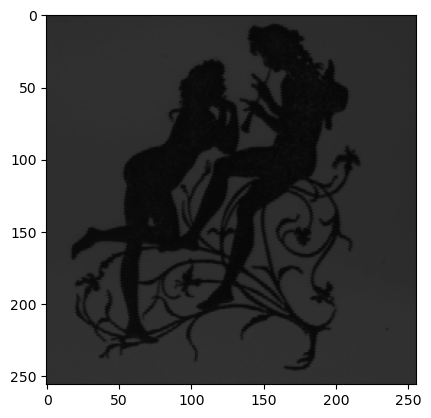

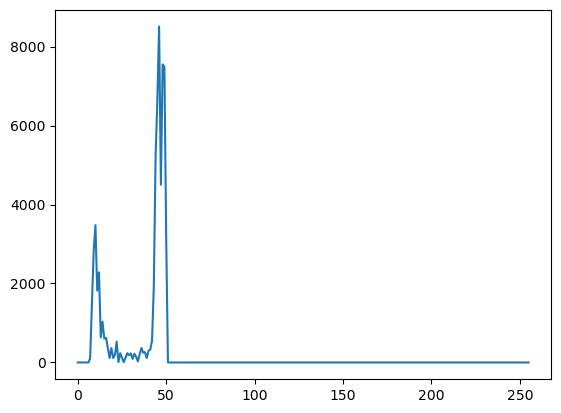

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel, prewitt
from skimage.filters import laplace
from skimage.filters import gaussian
from skimage.filters import threshold_local
from skimage.segmentation import flood
from skimage.feature import canny

image = cv2.imread("images/AMOUR.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma (MUSCLE)
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

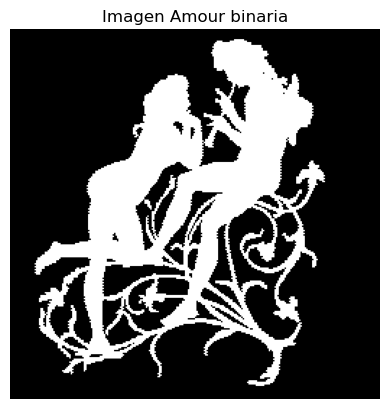

In [4]:
threshold = threshold_local(image, block_size=151, method='mean')
binary_image = image > threshold
thresholded_image = (binary_image*255).astype(np.uint8)
seed = (100, 100)
imagen_final = flood(thresholded_image, seed, tolerance=10)

plt.imshow(imagen_final, cmap='gray')
plt.title('Imagen Amour binaria')
plt.axis('off')
plt.show()

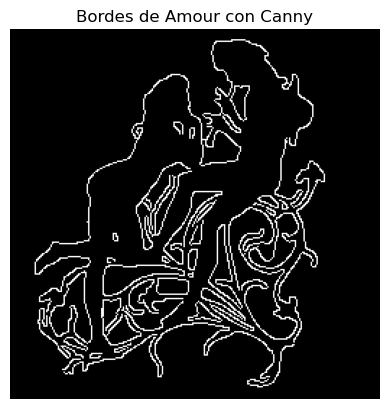

In [5]:
edges = canny(imagen_final, sigma=1, low_threshold=0, high_threshold=1)
plt.imshow(edges, cmap='gray')
plt.title('Bordes de Amour con Canny')
plt.axis('off')
plt.show()

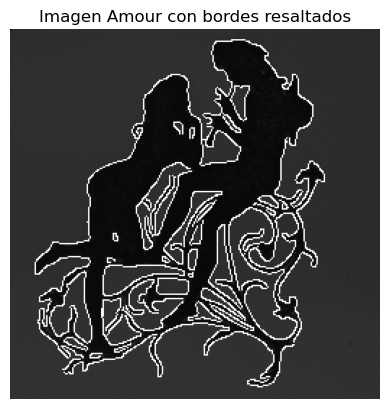

In [8]:
outlined = image.copy()

outlined[edges] = 255
plt.imshow(outlined, cmap='gray', vmin=0, vmax=255)

plt.axis('off')
plt.title('Imagen Amour con bordes resaltados')
plt.show()